In [1]:
!pip -q install duckdb huggingface_hub scikit-learn

from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# Hugging Face connection
token = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
con.execute("SET VARIABLE hf_token = ?", [token])

con.execute("""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN getvariable('hf_token')
)
""")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"

MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"
APR = f"read_parquet('{FACT}/month=2026-04/*.parquet')"

# March features
march = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS impressions_31d,
    SUM(gsc_clicks) AS clicks_31d,

    SUM(gsc_clicks) * 1.0 /
        NULLIF(SUM(gsc_impressions), 0) AS ctr_31d,

    SUM(gsc_sum_position) * 1.0 /
        NULLIF(SUM(gsc_impressions), 0) AS avg_position_31d,

    COALESCE(SUM(ga4_sessions), 0) AS sessions_31d

FROM {MAR}

WHERE gsc_data_available IS TRUE

GROUP BY client_hash_id, content_hash_id

HAVING SUM(gsc_impressions) >= 100
""").df()

# April outcome
april = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS april_impressions
FROM {APR}
WHERE gsc_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id
""").df()

model_df = march.merge(
    april,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_df["future_decline"] = (
    model_df["april_impressions"] <
    0.80 * model_df["impressions_31d"]
).astype(int)

features = [
    "impressions_31d",
    "clicks_31d",
    "ctr_31d",
    "avg_position_31d",
    "sessions_31d"
]

X = model_df[features].fillna(0)
y = model_df["future_decline"]
groups = model_df["client_hash_id"]

# Same grouped split as Week 5/6
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Final selected model
final_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

test_prob = final_model.predict_proba(X_test)[:, 1]

print("Action-playbook model ready.")
print("Test pages:", len(X_test))
print("Test clients:", groups.iloc[test_idx].nunique())

Action-playbook model ready.
Test pages: 15191
Test clients: 9


# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Malang43/flyrank-ml-internship-Malang43/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Purpose: The model produces a ranked review queue for the Refresh / Content Opportunity Scoring lane. Higher-ranked pages are reviewed first because they received higher estimated probability of meeting the study's future-decline proxy. The score is a prioritization signal, not an instruction to automatically modify content.

I use reason codes based only on observable pre-decision signals so that a human reviewer can understand why a page deserves attention. The highest-priority 50 pages form the primary review queue because Precision@50 is the validated operational metric.

In [2]:
# Build a public-safe action queue from held-out clients
queue = model_df.iloc[test_idx][
    [
        "client_hash_id",
        "content_hash_id",
        "impressions_31d",
        "clicks_31d",
        "ctr_31d",
        "avg_position_31d",
        "sessions_31d"
    ]
].copy()

queue["model_score"] = test_prob

# Thresholds learned only from training data
train_frame = model_df.iloc[train_idx]

ctr_q25 = train_frame["ctr_31d"].quantile(0.25)
ctr_median = train_frame["ctr_31d"].median()
clicks_q25 = train_frame["clicks_31d"].quantile(0.25)

def reason_code(row):
    if (
        row["avg_position_31d"] <= 20
        and row["ctr_31d"] <= ctr_q25
    ):
        return "low_ctr_at_visible_position"

    elif (
        row["impressions_31d"] >= 500
        and row["clicks_31d"] <= clicks_q25
    ):
        return "high_visibility_low_clicks"

    elif (
        row["avg_position_31d"] <= 10
        and row["ctr_31d"] <= ctr_median
    ):
        return "page_one_click_gap"

    else:
        return "combined_model_signal"

queue["reason_code"] = queue.apply(
    reason_code,
    axis=1
)

queue = queue.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

queue["rank"] = np.arange(1, len(queue) + 1)

# Operational actions based on review capacity
queue["action"] = np.select(
    [
        queue["rank"] <= 50,
        queue["rank"] <= 200
    ],
    [
        "review_now",
        "review_if_capacity"
    ],
    default="monitor"
)

display(
    queue[
        [
            "rank",
            "content_hash_id",
            "model_score",
            "reason_code",
            "action",
            "impressions_31d",
            "ctr_31d",
            "avg_position_31d"
        ]
    ].head(20)
)

,rank,content_hash_id,model_score,reason_code,action,impressions_31d,ctr_31d,avg_position_31d
0,1,content_9d9713f2a48067c8,0.717063,low_ctr_at_visible_position,review_now,771.0,0.000000,10.992218
1,2,content_c0407691d2c3c153,0.673936,page_one_click_gap,review_now,2482.0,0.000403,7.605963
2,3,content_cd3d932d4e1c8db0,0.671890,page_one_click_gap,review_now,89332.0,0.000045,7.831807
3,4,content_d8288f22519f7d53,0.660219,high_visibility_low_clicks,review_now,1225.0,0.000000,21.675918
4,5,content_2b74174acd8039c7,0.652543,low_ctr_at_visible_position,review_now,832.0,0.000000,7.974760
5,6,content_cf2264753938463b,0.649439,page_one_click_gap,review_now,46938.0,0.000234,4.260194
6,7,content_713b157e9c77690a,0.645506,low_ctr_at_visible_position,review_now,24908.0,0.000000,3.431106
7,8,content_dc91779c3d085398,0.643148,page_one_click_gap,review_now,25625.0,0.000039,2.389151
8,9,content_b215e9a73e2284ad,0.641889,low_ctr_at_visible_position,review_now,930.0,0.000000,13.822581
9,10,content_5b9f20eb3b7f872b,0.638169,page_one_click_gap,review_now,17617.0,0.000114,3.808764


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended user: A content or SEO reviewer who has limited capacity and needs to decide which pages should be inspected first.

Intended use: The queue prioritizes pages for manual diagnostic review. For the validated experiment, the top 50 pages are the primary review set.

Validated evidence: Logistic Regression achieved Precision@50 of 0.66 on a grouped holdout containing completely unseen clients, compared with 0.48 for the transparent Week-4 baseline.

Limits: The model was validated on the March-to-April 2026 prediction setting and should not be assumed to perform equally for every client or future period. Its score indicates measured review priority for the study's decline proxy; it does not prove that a page is defective or that editing the page will cause performance to improve.

In [3]:
use_summary = pd.DataFrame({
    "Item": [
        "Primary decision",
        "Primary review capacity",
        "Validated Precision@50",
        "Baseline Precision@50",
        "Validation design"
    ],
    "Value": [
        "Which pages should be reviewed first?",
        "Top 50 pages",
        "0.66",
        "0.48",
        "Client-grouped holdout"
    ]
})

use_summary

,Item,Value
0,Primary decision,Which pages should be reviewed first?
1,Primary review capacity,Top 50 pages
2,Validated Precision@50,0.66
3,Baseline Precision@50,0.48
4,Validation design,Client-grouped holdout


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Before acting on a recommendation, a human reviewer should check whether the apparent weakness has another explanation. Important checks include query or intent mix, seasonality, SERP changes, related-page consolidation, measurement availability, and whether the page's traffic volume is sufficient to support the recommendation.

The system must not automatically rewrite, delete, merge, prune, or publish content. It must also not claim that a recommendation will improve rankings or traffic. The queue is designed to prioritize investigation; the final content decision belongs to a human reviewer.

In [4]:
review_policy = pd.DataFrame({
    "Human check": [
        "Search intent / query mix",
        "Seasonality",
        "SERP or click-environment changes",
        "Related-page consolidation",
        "Measurement availability",
        "Traffic volume / noise"
    ],
    "Why check it": [
        "Low CTR may be normal for the queries served",
        "A temporary drop may be seasonal",
        "Clicks may fall even when visibility remains",
        "Another page may have absorbed demand",
        "Missing analytics data is not true zero activity",
        "Low-volume changes may be noise"
    ]
})

display(review_policy)

no_go = [
    "Automatically rewrite content",
    "Automatically delete or prune pages",
    "Automatically merge pages",
    "Claim that editing will cause rankings to improve",
    "Claim that the model discovered Google's algorithm",
    "Expose client names, URLs, or private queries"
]

print("\nNO-GO LIST")
for item in no_go:
    print("-", item)

,Human check,Why check it
0,Search intent / query mix,Low CTR may be normal for the queries served
1,Seasonality,A temporary drop may be seasonal
2,SERP or click-environment changes,Clicks may fall even when visibility remains
3,Related-page consolidation,Another page may have absorbed demand
4,Measurement availability,Missing analytics data is not true zero activity
5,Traffic volume / noise,Low-volume changes may be noise



NO-GO LIST
- Automatically rewrite content
- Automatically delete or prune pages
- Automatically merge pages
- Claim that editing will cause rankings to improve
- Claim that the model discovered Google's algorithm
- Expose client names, URLs, or private queries


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The model should be monitored because content behavior, client mix, search conditions, and measurement availability can change over time. The current validation result of Precision@50 = 0.66 is the reference performance.

I would trigger investigation or retraining if Precision@50 on a newly labeled evaluation period falls materially below the validated result, if it falls to or below the 0.48 rule-based baseline, if feature distributions or measurement availability change substantially, or if the model is applied to a new period or client population not represented by the current validation design.

These are operational monitoring rules rather than universal statistical thresholds and should be revised as more evaluation periods become available.

In [5]:
monitoring_triggers = pd.DataFrame({
    "Trigger": [
        "Precision@50 <= baseline",
        "Large drop from validated P@50",
        "Major feature-distribution shift",
        "Analytics availability changes",
        "New client population",
        "New search/time environment"
    ],
    "Response": [
        "Stop relying on model advantage and investigate",
        "Audit errors and consider retraining",
        "Check drift before using recommendations",
        "Review missing-data handling",
        "Run grouped validation again",
        "Run a new time-aware validation"
    ]
})

monitoring_triggers

,Trigger,Response
0,Precision@50 <= baseline,Stop relying on model advantage and investigate
1,Large drop from validated P@50,Audit errors and consider retraining
2,Major feature-distribution shift,Check drift before using recommendations
3,Analytics availability changes,Review missing-data handling
4,New client population,Run grouped validation again
5,New search/time environment,Run a new time-aware validation


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

I export the ranked review queue, final validation metrics, and reusable model-versus-baseline figure. These outputs will be used as evidence in the final deployed research paper. The queue contains only pseudonymized identifiers and public-safe aggregated metrics.

In [6]:
output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

paper_metrics = {
    "lane": "Refresh / Content Opportunity Scoring",
    "model": "Logistic Regression",
    "feature_window": "2026-03",
    "outcome_window": "2026-04",
    "validation": "client_group_holdout",
    "baseline_precision_at_50": 0.48,
    "model_precision_at_50": 0.66,
    "relative_improvement_pct": 37.5,
    "features": features
}

with open(
    output_dir / "capstone_model_metrics.json",
    "w"
) as f:
    json.dump(paper_metrics, f, indent=2)

print("Saved capstone_model_metrics.json")

Saved capstone_model_metrics.json


In [7]:
paper_queue = queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "reason_code",
        "action",
        "impressions_31d",
        "clicks_31d",
        "ctr_31d",
        "avg_position_31d",
        "sessions_31d"
    ]
].copy()

paper_queue.to_csv(
    output_dir / "action_playbook_queue.csv",
    index=False
)

print("Saved action_playbook_queue.csv")
print("Rows:", len(paper_queue))

Saved action_playbook_queue.csv
Rows: 15191


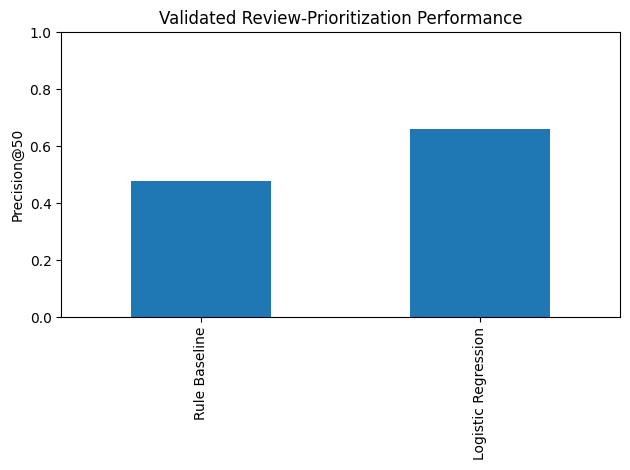

Saved: ../outputs/model_vs_baseline_precision50.png


In [8]:
figure_data = pd.DataFrame({
    "Method": [
        "Rule Baseline",
        "Logistic Regression"
    ],
    "Precision@50": [
        0.48,
        0.66
    ]
})

ax = figure_data.plot(
    x="Method",
    y="Precision@50",
    kind="bar",
    legend=False
)

ax.set_ylabel("Precision@50")
ax.set_xlabel("")
ax.set_title("Validated Review-Prioritization Performance")
ax.set_ylim(0, 1)

plt.tight_layout()

figure_path = (
    output_dir /
    "model_vs_baseline_precision50.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.